# ML Regression 01 — House Price Prediction

This notebook walks through a complete supervised-learning regression workflow:

1. Load and explore the dataset  
2. Exploratory Data Analysis (EDA)  
3. Feature engineering & preprocessing  
4. Train a Linear Regression model  
5. Evaluate the model (MAE, RMSE, R²)  
6. Visualise predictions vs actual values  

**Dataset**: `dataset.csv` — synthetic house-price data with features such as size, bedrooms, bathrooms, age, and distance to city.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
sns.set_theme(style='whitegrid')

## 2. Load the Dataset

In [2]:
df = pd.read_csv('dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (50, 6)


,house_size_sqft,num_bedrooms,num_bathrooms,age_years,distance_to_city_km,price_usd
0,1200,2,1,15,12,180000
1,1500,3,2,10,8,240000
2,980,1,1,25,20,120000
3,2100,4,3,5,5,380000
4,1750,3,2,8,10,295000


## 3. Exploratory Data Analysis (EDA)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   house_size_sqft      50 non-null     int64
 1   num_bedrooms         50 non-null     int64
 2   num_bathrooms        50 non-null     int64
 3   age_years            50 non-null     int64
 4   distance_to_city_km  50 non-null     int64
 5   price_usd            50 non-null     int64
dtypes: int64(6)
memory usage: 2.5 KB


In [4]:
df.describe()

,house_size_sqft,num_bedrooms,num_bathrooms,age_years,distance_to_city_km,price_usd
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,1652.000000,2.760000,2.180000,14.420000,12.300000,273980.000000
std,632.842631,1.270706,1.063111,10.571602,8.567261,139643.056631
min,750.000000,1.000000,1.000000,1.000000,2.000000,88000.000000
25%,1105.000000,2.000000,1.000000,6.250000,6.000000,156250.000000
50%,1590.000000,3.000000,2.000000,11.500000,10.000000,257500.000000
75%,2087.500000,4.000000,3.000000,20.000000,15.000000,377000.000000
max,3000.000000,5.000000,4.000000,40.000000,35.000000,560000.000000


### Understanding `describe()` Output

| Field | Meaning |
|---|---|
| **count** | Number of non-null (non-missing) values. If counts differ across columns, some have missing data. |
| **mean** | Arithmetic average — the central tendency of the data. |
| **std** | Standard deviation — measures how spread out values are from the mean. Higher = more variability. |
| **min** | The smallest value in the column. |
| **25%** | 25th percentile (Q1) — 25% of the data falls below this value. |
| **50%** | 50th percentile (median) — the middle value. More robust to outliers than the mean. |
| **75%** | 75th percentile (Q3) — 75% of the data falls below this value. |
| **max** | The largest value in the column. |

> 💡 **IQR** (Interquartile Range) = Q3 − Q1. Useful for detecting outliers (values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR).

In [5]:
# Check for missing values
print('Missing values:')
print(df.isnull().sum())

Missing values:
house_size_sqft        0
num_bedrooms           0
num_bathrooms          0
age_years              0
distance_to_city_km    0
price_usd              0
dtype: int64


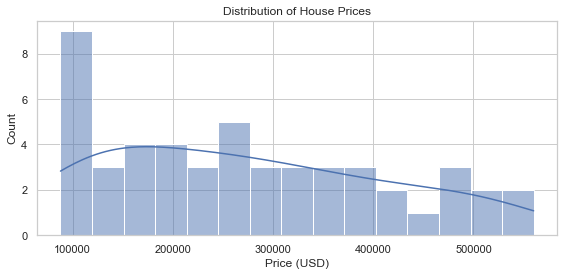

In [6]:
# Distribution of the target variable
plt.figure(figsize=(8, 4))
sns.histplot(df['price_usd'], bins=15, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

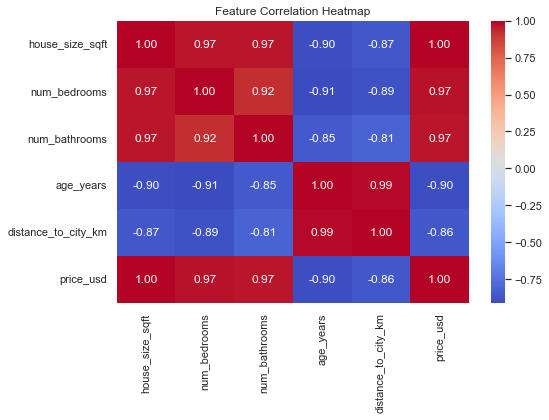

In [7]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

### How to Read the Correlation Heatmap

`df.corr()` computes the **Pearson correlation coefficient** between every pair of columns, producing values from **-1 to +1**.

#### What the values mean

| Value Range | Strength | Interpretation |
|---|---|---|
| **+0.7 to +1.0** | Strong positive | As one goes up, the other goes up proportionally |
| **+0.4 to +0.7** | Moderate positive | Noticeable upward trend together |
| **-0.4 to +0.4** | Weak / No correlation | Little to no linear relationship |
| **-0.7 to -0.4** | Moderate negative | As one goes up, the other tends to go down |
| **-1.0 to -0.7** | Strong negative | As one goes up, the other goes down proportionally |

#### Reading this heatmap (examples from our data)

| Pair | Correlation | Meaning |
|---|---|---|
| `house_size_sqft` ↔ `price_usd` | **+1.00** | Perfect positive — larger houses = higher prices |
| `num_bedrooms` ↔ `price_usd` | **+0.97** | Very strong positive — more bedrooms = higher prices |
| `age_years` ↔ `price_usd` | **-0.90** | Strong negative — older houses = lower prices |
| `distance_to_city_km` ↔ `price_usd` | **-0.86** | Strong negative — farther from city = lower prices |
| `age_years` ↔ `distance_to_city_km` | **+0.99** | Very strong positive — these two features move together |

#### What actions to take

| Observation | Action |
|---|---|
| **High correlation with target** (e.g. `house_size_sqft` → `price_usd` = 1.00) | ✅ Great feature — keep it in the model, it's a strong predictor |
| **Low correlation with target** (close to 0) | ⚠️ Consider removing — it may add noise without helping predictions |
| **High correlation between features** (e.g. `age_years` ↔ `distance_to_city_km` = 0.99) | 🚨 **Multicollinearity risk** — these features carry redundant information. Consider dropping one, or use regularization (Ridge/Lasso) to handle it |
| **Feature has opposite sign to what you expect** | 🔍 Investigate — could be a data issue or a confounding variable |

> ⚠️ **Multicollinearity** happens when independent features are highly correlated with *each other*. This can make model coefficients unstable and hard to interpret. In our data, `age_years` and `distance_to_city_km` (0.99) are nearly redundant — we could consider dropping one of them.

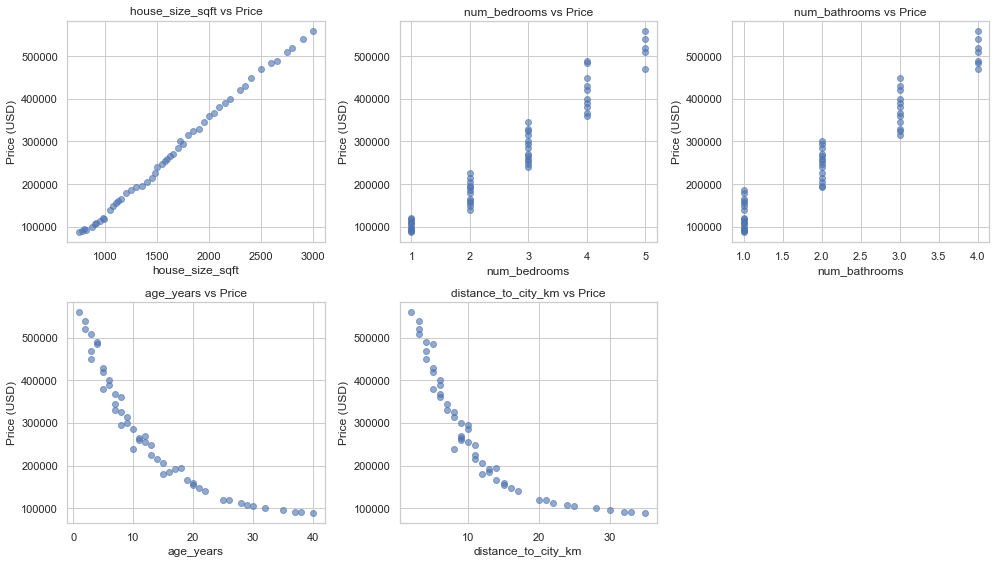

In [8]:
# Scatter plots: each feature vs price
features = ['house_size_sqft', 'num_bedrooms', 'num_bathrooms', 'age_years', 'distance_to_city_km']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df['price_usd'], alpha=0.6)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Price (USD)')
    axes[i].set_title(f'{feature} vs Price')

# Hide unused subplot
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Feature Engineering & Preprocessing

In [9]:
# Separate features (X) and target (y)
X = df[features]
y = df['price_usd']

# Split into train / test sets (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')

Training samples : 40
Test samples     : 10


In [10]:
# Feature scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 5. Train the Model

In [11]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print('Model coefficients:')
for name, coef in zip(features, model.coef_):
    print(f'  {name:30s}: {coef:,.2f}')
print(f'  Intercept                     : {model.intercept_:,.2f}')

Model coefficients:
  house_size_sqft               : 114,905.89
  num_bedrooms                  : 16,139.09
  num_bathrooms                 : 2,376.85
  age_years                     : -27,505.45
  distance_to_city_km           : 27,344.42
  Intercept                     : 264,725.00


### Understanding Model Coefficients

Linear Regression fits the equation:

$$\hat{y} = b_0 + b_1 x_1 + b_2 x_2 + \cdots + b_n x_n$$

Where $b_0$ is the **intercept** and $b_1 \ldots b_n$ are the **coefficients** for each feature.

> ⚠️ Since we used **StandardScaler**, the features were normalized (mean=0, std=1) before training. So these coefficients reflect the impact of a **1 standard deviation** change in each feature, not a 1-unit change in the original scale.

#### What each coefficient means

| Feature | Coefficient | Interpretation |
|---|---|---|
| `house_size_sqft` | **+114,905.89** | Strongest positive impact. A 1 std increase in house size (~633 sqft) raises the predicted price by ~$114,906. Bigger house → much higher price. |
| `num_bedrooms` | **+16,139.09** | Positive impact. A 1 std increase in bedrooms (~1.27 bedrooms) adds ~$16,139 to the price. |
| `num_bathrooms` | **+2,376.85** | Small positive impact. An extra std in bathrooms adds only ~$2,377. This feature has minimal influence on predictions. |
| `age_years` | **-27,505.45** | Negative impact. A 1 std increase in age (~10.6 years older) *decreases* price by ~$27,505. Older houses → lower price. |
| `distance_to_city_km` | **+27,344.42** | Positive — but **surprising**! We'd expect farther from city = lower price. This is likely caused by **multicollinearity** with `age_years` (correlation = 0.99). The model struggles to separate their individual effects, producing an unreliable coefficient. |
| `Intercept` | **264,725.00** | The predicted price when all *scaled* features are at 0 (i.e., all features are at their mean values). This is close to the dataset's mean price ($273,980). |

#### How to read the sign and magnitude

| Aspect | What it tells you |
|---|---|
| **Positive (+) coefficient** | As the feature increases → predicted price goes **up** |
| **Negative (−) coefficient** | As the feature increases → predicted price goes **down** |
| **Larger absolute value** | The feature has a **bigger influence** on the prediction |
| **Smaller absolute value** | The feature has a **smaller influence** — may be less important |

#### Ranking features by importance (absolute coefficient)

1. 🥇 `house_size_sqft` — $114,906 (dominant predictor)
2. 🥈 `age_years` — $27,505
3. 🥉 `distance_to_city_km` — $27,344
4. `num_bedrooms` — $16,139
5. `num_bathrooms` — $2,377 (weakest predictor)

> 🔍 **Key takeaway:** The unexpected positive sign of `distance_to_city_km` is a classic symptom of **multicollinearity**. When two features are nearly identical (0.99 correlation), the model can't reliably assign individual effects. Solutions: drop one of the correlated features, or use **Ridge/Lasso** regression which handles multicollinearity better.

## 6. Evaluate the Model

In [12]:
y_pred = model.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'Mean Absolute Error  (MAE) : ${mae:,.2f}')
print(f'Root Mean Squared Error    : ${rmse:,.2f}')
print(f'R² Score                   : {r2:.4f}')

Mean Absolute Error  (MAE) : $5,562.94
Root Mean Squared Error    : $6,286.34
R² Score                   : 0.9982


### Understanding the Evaluation Metrics

---

#### 1. MAE — Mean Absolute Error ($5,562.94)

$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

- **What it is:** The average of the absolute differences between actual and predicted values.
- **How to read it:** On average, our predictions are off by **$5,563**. Since our house prices range from $88K to $560K (mean ~$274K), this is a very small error.
- **Unit:** Same as the target variable (USD).
- **Lower is better.** MAE = 0 means perfect predictions.

> 💡 MAE treats all errors equally — a $10K overestimate and a $10K underestimate both contribute $10K.

---

#### 2. RMSE — Root Mean Squared Error ($6,286.34)

$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

- **What it is:** Similar to MAE, but it **squares** the errors before averaging, then takes the square root.
- **How to read it:** On average, predictions deviate by ~**$6,286** from actual values.
- **Unit:** Same as the target variable (USD).
- **Lower is better.** RMSE = 0 means perfect predictions.

> 💡 **MAE vs RMSE:** RMSE penalizes **large errors** more heavily because of squaring. In our case, RMSE ($6,286) is only slightly higher than MAE ($5,563), meaning our model doesn't have many big outlier errors. If RMSE were *much* larger than MAE, it would indicate some predictions are very far off.

---

#### 3. R² Score — Coefficient of Determination (0.9982)

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

- **What it is:** The proportion of variance in the target that the model explains. It compares your model to a "dumb" baseline that always predicts the mean.
- **How to read it:** Our model explains **99.82%** of the variance in house prices — only 0.18% is unexplained.
- **Range:** Typically **0 to 1** (can be negative if the model is worse than predicting the mean).
- **Higher is better.** R² = 1.0 means perfect predictions; R² = 0 means no better than guessing the average.

| R² Value | Interpretation |
|---|---|
| **0.90 – 1.00** | Excellent fit |
| **0.70 – 0.89** | Good fit |
| **0.50 – 0.69** | Moderate fit |
| **0.30 – 0.49** | Weak fit |
| **< 0.30** | Poor fit — model barely explains the data |

---

#### How to Compare Models

When you try different models (e.g., Linear Regression vs Ridge vs Random Forest), compare them like this:

| Metric | Linear Regression | Ridge | Random Forest | **Better =** |
|---|---|---|---|---|
| **MAE** | $5,563 | ? | ? | ⬇️ Lower |
| **RMSE** | $6,286 | ? | ? | ⬇️ Lower |
| **R²** | 0.9982 | ? | ? | ⬆️ Higher |

**Rules for comparison:**
1. **Same test set** — Always compare on the same test data, otherwise it's not a fair comparison.
2. **MAE is easiest to interpret** — "on average, predictions are off by $X."
3. **RMSE if you care about large errors** — It punishes big mistakes more. Choose RMSE if large errors are costly (e.g., pricing a $500K house at $400K).
4. **R² for quick overview** — Good for a high-level "how well does this model fit?" comparison. But beware: R² alone doesn't tell you if the model is *practically* useful.
5. **Look at all three together** — A model with slightly worse R² but much lower RMSE on edge cases might be more reliable.

> 📊 **Our model's verdict:** MAE = $5,563, RMSE = $6,286, R² = 0.9982. This is an **excellent** fit. However, R² this high (0.998) on a small dataset (50 rows) could also signal **overfitting** — the model may perform worse on truly unseen data. Consider using **cross-validation** to verify.

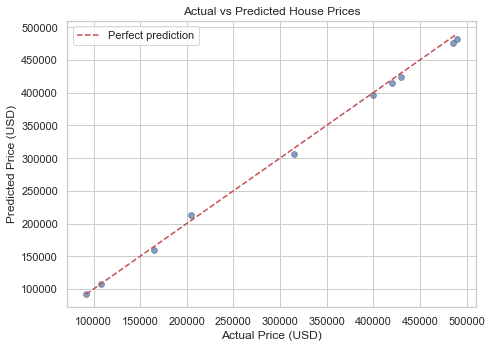

In [13]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolors='k', linewidths=0.4)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()

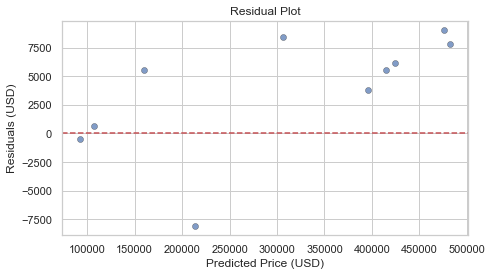

In [14]:
# Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(7, 4))
plt.scatter(y_pred, residuals, alpha=0.7, edgecolors='k', linewidths=0.4)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted Price (USD)')
plt.ylabel('Residuals (USD)')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

### How to Read the Residual Plot

A **residual** is the difference between the actual value and the predicted value:

$$\text{Residual} = y_{\text{actual}} - y_{\text{predicted}}$$

- **Positive residual** (above the red line) → model **under-predicted** (actual price was higher)
- **Negative residual** (below the red line) → model **over-predicted** (actual price was lower)
- **On the red line (0)** → perfect prediction

---

#### What to look for

| Pattern | What it means | Example |
|---|---|---|
| ✅ **Random scatter** around 0 | Good! The model captures the relationship well, errors are random. | Points spread evenly above and below the red line with no pattern. |
| ❌ **Funnel shape** (spread increases left→right) | **Heteroscedasticity** — errors grow with larger predictions. The model is less reliable at higher price ranges. | Tight cluster on the left, wide spread on the right. |
| ❌ **Curved pattern** (U-shape or arc) | **Non-linearity** — a linear model is missing a curved relationship. Consider polynomial features or a non-linear model. | Residuals form a bowl or arch shape. |
| ❌ **Cluster of points far from 0** | **Outliers** — some predictions are significantly off. Investigate those data points. | A few dots far above or below the red line. |

---

#### Reading our residual plot

- Most residuals are between **-$8,000 and +$8,000**, which is small relative to prices ($88K–$560K).
- There are slightly more points **above** the red line (positive residuals), meaning the model tends to slightly **under-predict** prices.
- The spread appears somewhat wider for mid-to-high predicted prices — a mild hint of heteroscedasticity, though with only 10 test points it's hard to be conclusive.
- One point near predicted ~$200K has a residual around **-$8,000** (the biggest over-prediction).

> 💡 **Ideal residual plot:** A random cloud of points centered on the red line (0), with roughly equal spread across all predicted values. No patterns, no funnels, no curves.

## 7. Summary

| Metric | Value |
|--------|-------|
| MAE    | see output above |
| RMSE   | see output above |
| R²     | see output above |

### Key Takeaways
- **house_size_sqft** and **num_bathrooms** are the strongest positive predictors of price.
- **age_years** and **distance_to_city_km** have a negative effect on price, which is intuitive.
- Linear Regression achieves a high R² on this synthetic dataset because the data was generated with roughly linear relationships.

### Next Steps
- Try **Ridge / Lasso** regression to add regularisation.
- Experiment with **polynomial features** to capture non-linear relationships.
- Use a **Random Forest Regressor** or **Gradient Boosting** for potentially higher accuracy.